<a href="https://colab.research.google.com/github/OneStack-x/Customer-Segmentation-using-K-Means-Clustering/blob/main/Online_Retail_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
import kagglehub
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

100%|██████████| 14.5M/14.5M [00:00<00:00, 74.9MB/s]

Extracting files...


In [3]:
print(path)

/root/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/versions/3


In [7]:
import os

os.listdir(path)
csv_path = os.path.join(path, "online_retail_II.csv")

df = pd.read_csv(csv_path)

In [9]:
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [10]:
df.shape

(1067371, 8)

In [11]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [13]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [15]:
a=df.duplicated().sum()
print(a)

34335


In [16]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
676951,549556,22523,CHILDS GARDEN FORK PINK,3,2011-04-10 12:53:00,0.85,17372.0,United Kingdom
969968,574733,22941,CHRISTMAS LIGHTS 10 REINDEER,4,2011-11-06 15:17:00,8.50,17082.0,United Kingdom
888731,568556,23157,SET OF 6 NATIVITY MAGNETS,12,2011-09-27 15:35:00,2.08,15827.0,United Kingdom
1021820,578344,23242,TREASURE TIN BUFFALO BILL,1,2011-11-24 09:21:00,4.13,NaN,United Kingdom
72600,495952,21668,RED STRIPE CERAMIC DRAWER KNOB,2,2010-01-27 17:53:00,2.51,NaN,United Kingdom
900421,569414,22114,HOT WATER BOTTLE TEA AND SYMPATHY,34,2011-10-04 10:11:00,9.13,NaN,United Kingdom
306249,519246,15056BL,EDWARDIAN PARASOL BLACK,24,2010-08-15 14:34:00,5.95,NaN,EIRE
877396,567670,21934,SKULL SHOULDER BAG,18,2011-09-21 15:32:00,1.63,NaN,United Kingdom
1020281,578275,85036C,ROSE 1 WICK MORRIS BOXED CANDLE,1,2011-11-23 13:46:00,1.25,15916.0,United Kingdom
680580,549966,22245,"HOOK, 1 HANGER ,MAGIC GARDEN",12,2011-04-13 14:17:00,0.85,16224.0,United Kingdom


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [19]:
df.isnull().sum()
df = df.dropna(subset=["Customer ID"])

In [21]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [22]:
#(1067371, 8)
df.shape

(824364, 8)

In [24]:
a=(df["Quantity"] <= 0).sum()
print(a)

18744


In [25]:
df = df[df["Quantity"] > 0]

# ***Remove Zero or Negative Prices***

In [26]:
df = df[df["Price"] > 0]

In [30]:
df["InvoiceDate"]

,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00
...,...
1067366,2011-12-09 12:50:00
1067367,2011-12-09 12:50:00
1067368,2011-12-09 12:50:00
1067369,2011-12-09 12:50:00


In [31]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [34]:
df["InvoiceDate"].max()

'2011-12-09 12:50:00'

In [44]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [45]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [46]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [48]:
rfm.shape

(5878, 3)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [50]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.595584,0.438998,5.058050
12347.0,-0.952279,0.131502,0.177431
12348.0,-0.603532,-0.099120,-0.067806
12349.0,-0.871064,-0.175994,0.095686
12350.0,0.519146,-0.406616,-0.182148


In [51]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

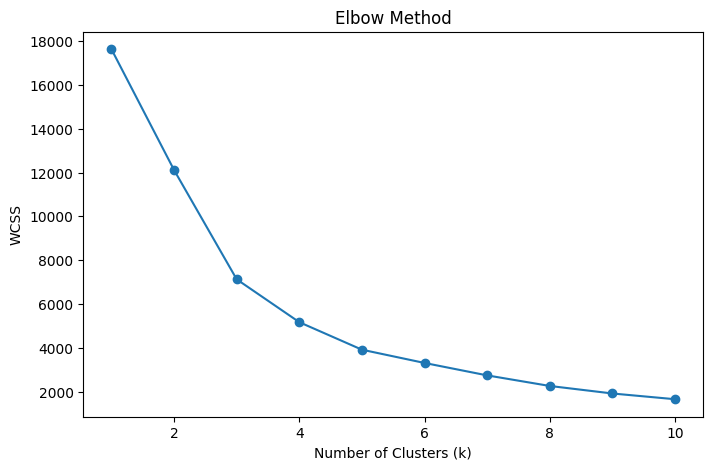

In [52]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [85]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(rfm_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [86]:
rfm["Cluster"] = kmeans.labels_

In [87]:
rfm["Cluster"].value_counts()

,count
Cluster,
1,3841
0,1998
2,35
3,4


In [88]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


# **Visualization**

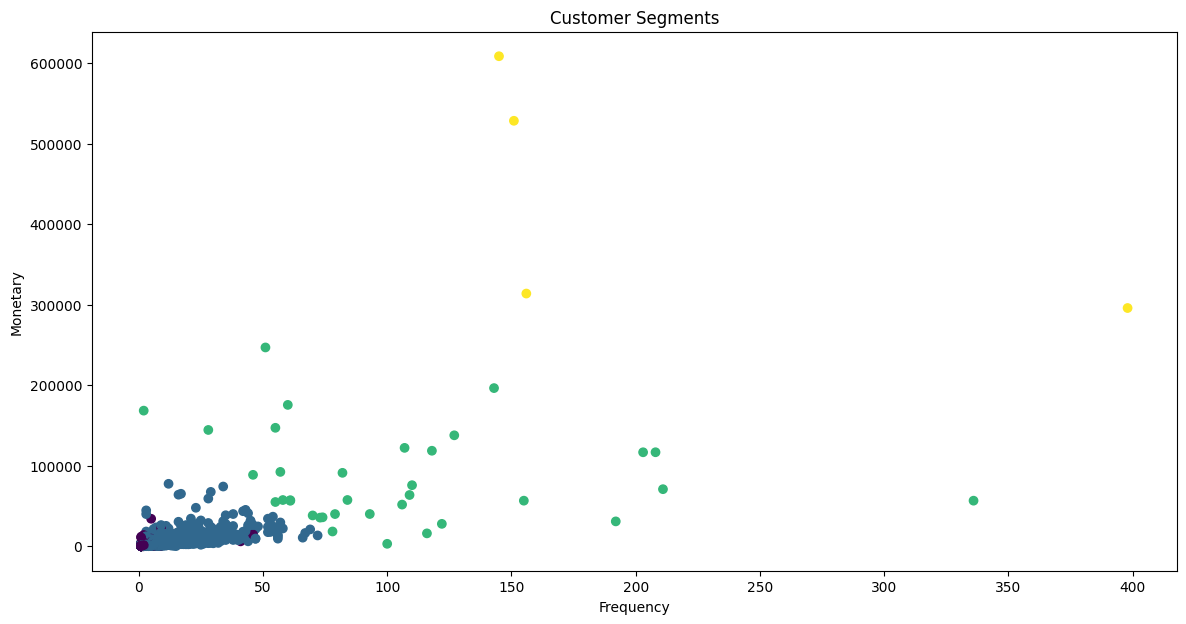

In [89]:
plt.figure(figsize=(14,7))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")

plt.show()

In [90]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, kmeans.labels_)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.591
